In [1]:
from astropy import constants as const
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

NR = 205
NZ = 205
NT = 1000
Rf = np.linspace(-2,202,NR)
Zf = np.linspace(-2,202,NZ)
Rc = (Rf[1:] + Rf[:-1]) /2
Zc = (Zf[1:] + Zf[:-1]) /2
dV = Rc[:, None] * np.diff(Rf)[:,None] * np.diff(Zf)[None,:]
t = np.arange(NT)*1e4
c_lst = ["red", "blue", "orange", "green", "purple", "yellow", "cyan", "magenta", "black", "pink", "lime"]
def numerical_diffusion(ndis):
    N_tot = np.sum(ndis * dV[None,:], axis = (1,2))
    mc_R = np.sum(ndis * Rc[None, :, None] * dV[None,:], axis = (1,2)) / N_tot
    mc_Z = np.sum(ndis * Zc[None, None, :] * dV[None,:], axis = (1,2)) / N_tot
    
    sigma_R = np.sum((Rc[None,:,None] - mc_R[:,None,None])**2 * ndis * dV[None,:], axis = (1,2)) / N_tot 
    sigma_Z = np.sum((Zc[None,None,:] - mc_Z[:,None,None])**2 * ndis * dV[None,:], axis = (1,2)) / N_tot 
    cov = np.sum((Rc[None,:,None]-mc_R[:,None,None])*(Zc[None,None,:]-mc_Z[:,None,None])*ndis*dV[None,:,:],axis=(1,2))/N_tot
    D_R = (sigma_R[1:] - sigma_R[0]) / 2 / t[1:] 
    D_Z = (sigma_Z[1:] - sigma_Z[0]) / 2 / t[1:] 

    return N_tot, mc_R, mc_Z, sigma_R, sigma_Z, cov, D_R, D_Z


In [2]:
NT = 1000
ndis_dx1_dt1e4 = np.fromfile("ndis_C_transport_dx1_dt1e4.bin",dtype = np.float64).reshape(NT, NR - 1, NZ - 1)
fig, ax = plt.subplots()

ndis_log = np.log10(ndis_dx1_dt1e4 + 1e-100)
ndis = ax.pcolormesh(Rc, Zc, ndis_log[0].T,shading="auto", vmin = -3, vmax = -1 )

cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('log scale') 

def animate(i):
    ndis.set_array(ndis_log[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=NT,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

Text(0.5, 1.0, 'D_num')

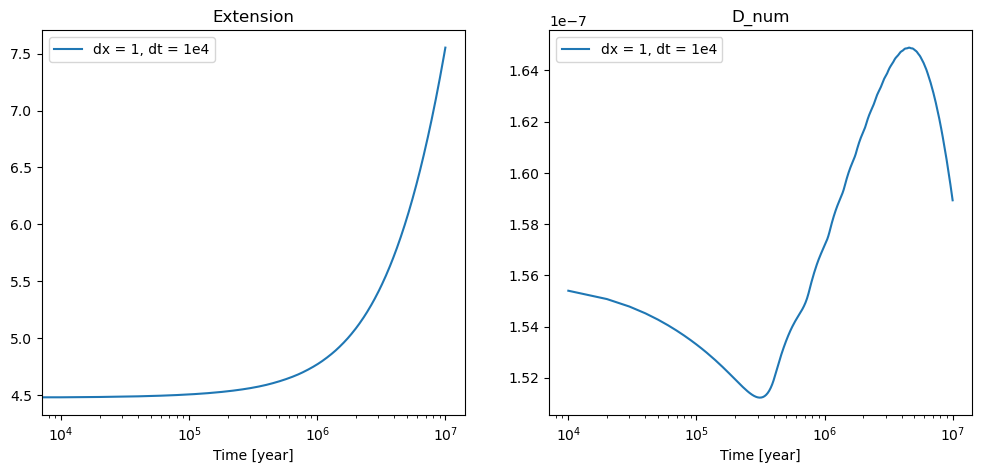

In [17]:
nd_dx1_dt1e4 = numerical_diffusion(ndis_dx1_dt1e4)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, nd_dx1_dt1e4[3], label="dx = 1, dt = 1e4")
axes[0].legend()
axes[0].set_xscale("log")
# axes[0].set_yscale("log")
axes[0].set_xlabel("Time [year]")
axes[0].set_title("Extension")

axes[1].plot(t[1:], nd_dx1_dt1e4[7], label="dx = 1, dt = 1e4")
axes[1].legend()
axes[1].set_xscale("log")
axes[1].set_xlabel("Time [year]")
axes[1].set_title("D_num")

In [18]:
NR = 405
NZ = 405
NT = 1000
Rf = np.linspace(-1,201,NR)
Zf = np.linspace(-1,201,NZ)
Rc = (Rf[1:] + Rf[:-1]) /2
Zc = (Zf[1:] + Zf[:-1]) /2
dV = Rc[:, None] * np.diff(Rf)[:,None] * np.diff(Zf)[None,:]
t = np.arange(NT)*1e4
c_lst = ["red", "blue", "orange", "green", "purple", "yellow", "cyan", "magenta", "black", "pink", "lime"]
def numerical_diffusion(ndis):
    N_tot = np.sum(ndis * dV[None,:], axis = (1,2))
    mc_R = np.sum(ndis * Rc[None, :, None] * dV[None,:], axis = (1,2)) / N_tot
    mc_Z = np.sum(ndis * Zc[None, None, :] * dV[None,:], axis = (1,2)) / N_tot
    
    sigma_R = np.sum((Rc[None,:,None] - mc_R[:,None,None])**2 * ndis * dV[None,:], axis = (1,2)) / N_tot 
    sigma_Z = np.sum((Zc[None,None,:] - mc_Z[:,None,None])**2 * ndis * dV[None,:], axis = (1,2)) / N_tot 
    cov = np.sum((Rc[None,:,None]-mc_R[:,None,None])*(Zc[None,None,:]-mc_Z[:,None,None])*ndis*dV[None,:,:],axis=(1,2))/N_tot
    D_R = (sigma_R[1:] - sigma_R[0]) / 2 / t[1:] 
    D_Z = (sigma_Z[1:] - sigma_Z[0]) / 2 / t[1:] 

    return N_tot, mc_R, mc_Z, sigma_R, sigma_Z, cov, D_R, D_Z

Text(0.5, 1.0, 'D_num')

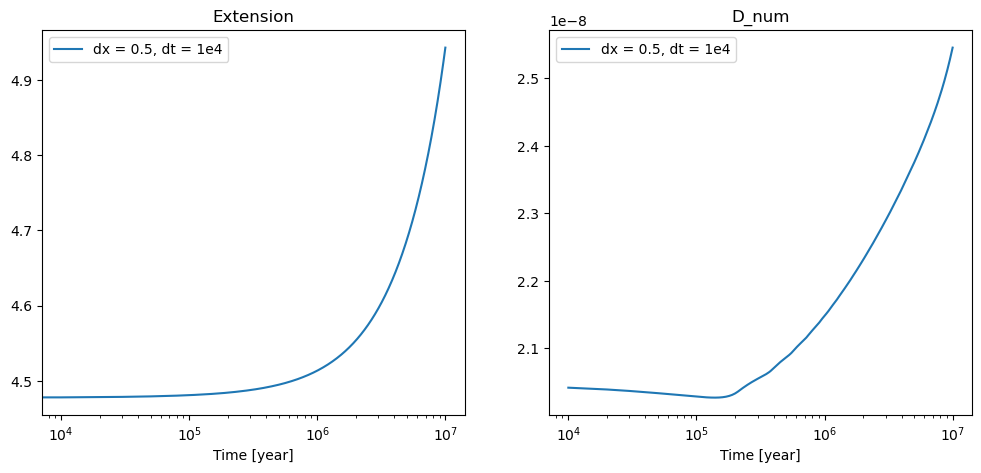

In [23]:
NT = 1000
ndis_dx05_dt1e4 = np.fromfile("ndis_C_transport_dx05_dt1e4.bin",dtype = np.float64).reshape(NT, NR - 1, NZ - 1)
nd_dx05_dt1e4 = numerical_diffusion(ndis_dx05_dt1e4)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, nd_dx05_dt1e4[3], label="dx = 0.5, dt = 1e4")
axes[0].legend()
axes[0].set_xscale("log")
# axes[0].set_yscale("log")
axes[0].set_xlabel("Time [year]")
axes[0].set_title("Extension")

axes[1].plot(t[1:], nd_dx05_dt1e4[7], label="dx = 0.5, dt = 1e4")
axes[1].legend()
axes[1].set_xscale("log")
axes[1].set_xlabel("Time [year]")
axes[1].set_title("D_num")

In [24]:
NR = 1005
NZ = 1005
NT = 1000
Rf = np.linspace(-1,201,NR)
Zf = np.linspace(-1,201,NZ)
Rc = (Rf[1:] + Rf[:-1]) /2
Zc = (Zf[1:] + Zf[:-1]) /2
dV = Rc[:, None] * np.diff(Rf)[:,None] * np.diff(Zf)[None,:]
t = np.arange(NT)*1e4
c_lst = ["red", "blue", "orange", "green", "purple", "yellow", "cyan", "magenta", "black", "pink", "lime"]
def numerical_diffusion(ndis):
    N_tot = np.sum(ndis * dV[None,:], axis = (1,2))
    mc_R = np.sum(ndis * Rc[None, :, None] * dV[None,:], axis = (1,2)) / N_tot
    mc_Z = np.sum(ndis * Zc[None, None, :] * dV[None,:], axis = (1,2)) / N_tot
    
    sigma_R = np.sum((Rc[None,:,None] - mc_R[:,None,None])**2 * ndis * dV[None,:], axis = (1,2)) / N_tot 
    sigma_Z = np.sum((Zc[None,None,:] - mc_Z[:,None,None])**2 * ndis * dV[None,:], axis = (1,2)) / N_tot 
    cov = np.sum((Rc[None,:,None]-mc_R[:,None,None])*(Zc[None,None,:]-mc_Z[:,None,None])*ndis*dV[None,:,:],axis=(1,2))/N_tot
    D_R = (sigma_R[1:] - sigma_R[0]) / 2 / t[1:] 
    D_Z = (sigma_Z[1:] - sigma_Z[0]) / 2 / t[1:] 

    return N_tot, mc_R, mc_Z, sigma_R, sigma_Z, cov, D_R, D_Z

In [ ]:
NT = 1000
ndis_dx02_dt1e4 = np.fromfile("ndis_C_transport_dx02_dt1e4.bin",dtype = np.float64).reshape(NT, NR - 1, NZ - 1)
nd_dx02_dt1e4 = numerical_diffusion(ndis_dx02_dt1e4)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t, nd_dx02_dt1e4[3], label="dx = 0.2, dt = 1e4")
axes[0].legend()
axes[0].set_xscale("log")
# axes[0].set_yscale("log")
axes[0].set_xlabel("Time [year]")
axes[0].set_title("Extension")

axes[1].plot(t[1:], nd_dx02_dt1e4[7], label="dx = 0.2, dt = 1e4")
axes[1].legend()
axes[1].set_xscale("log")
axes[1].set_xlabel("Time [year]")
axes[1].set_title("D_num")